Dans ce script, nous allons tester différents modèles de réseaux convolutionnels pour examiner leur performance. Nous allons ensuite tester s'ils sont robustes lorsqu'on applique une rotation à l'image d'entrée.

In [ ]:
import retinoto_py as fovea
model_name = 'convnext_base'
args = fovea.Params(do_fovea=True, model_name=model_name)
args

# learning the `convnext_base` on the 'focus' retinotopic images

In [ ]:
%ls -lh "cached_data/45_"*

In [ ]:
# %rm "cached_data/45_focus_model_name=convnext_base_dataset=bbox"*  # FORCING RECOMPUTE
# %rm "cached_data/45_focus_model_name=convnext_base_dataset=bbox.lock"  # FORCING RECOMPUTE
# %rm cached_data/45_focus_model_name*  # FORCING RECOMPUTE
# %rm cached_data/45_focus_model_name*.lock  # FORCING RECOMPUTE

In [ ]:
dataset = 'bbox'
init_model_filename = args.data_cache / f'32_fovea_model_name={args.model_name}_dataset={dataset}.pth'

In [ ]:
dataset = 'focus'
name = f'45_focus_model_name={args.model_name}_dataset={dataset}'
model_filename, json_filename = fovea.do_learning(args, dataset, name, init_model_filename=init_model_filename)

# Evaluation on the validation dataset

In [ ]:
model_name, dataset, len(results)

('convnext_base', 'bbox', 340)

In [ ]:
results = fovea.pd.read_json(args.data_cache / f'45_focus_model_name={model_name}_dataset={dataset}.json')
print(model_name, dataset, '- Accuracy=', results.tail(1)['acc_val'].item())

convnext_base bbox - Accuracy= 0.7999104299


In [ ]:
results.tail(10)

,epoch,i_image,total_image,loss_train,acc_train,acc_val,time
330,330,615168,6766848,0.483648,0.868927,0.799910,109355.664110
331,331,615168,7382016,0.484640,0.868216,0.799786,119284.880050
332,332,615168,7997184,0.482992,0.869250,0.799948,129209.733218
333,333,615168,8612352,0.484030,0.868938,0.799886,139138.229116
334,334,615168,9227520,0.484446,0.868551,0.800010,149065.186179
335,335,615168,9842688,0.483539,0.869574,0.799724,158998.846803
336,336,615168,10457856,0.481859,0.869483,0.799898,168931.587730
337,337,615168,11073024,0.485018,0.868642,0.799960,178873.168773
338,338,615168,11688192,0.481606,0.869480,0.800022,188810.792622
339,339,615168,12303360,0.482582,0.869332,0.799910,198746.495890


## Plot learning evolution

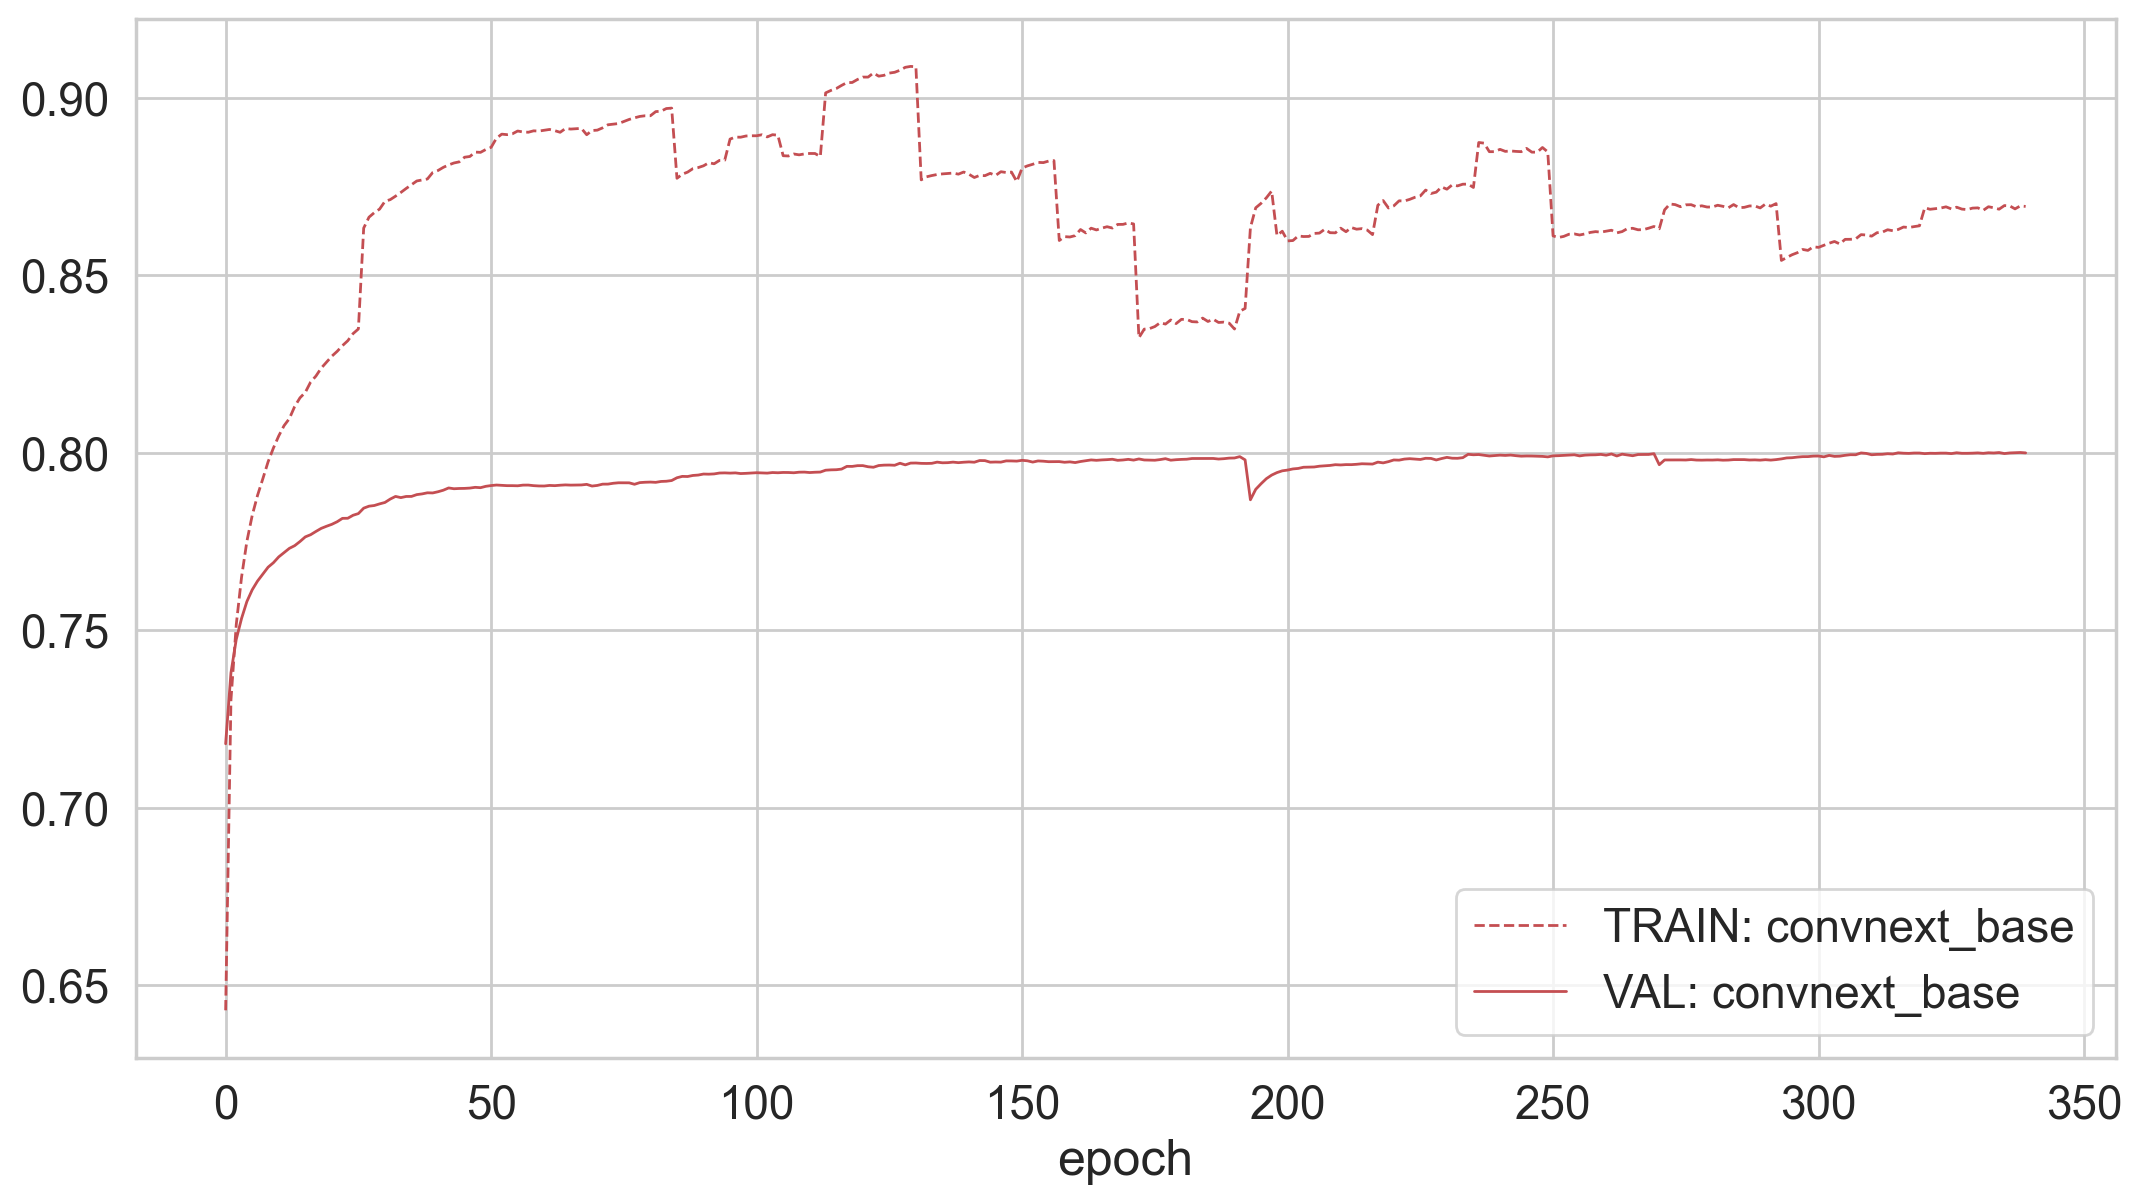

In [ ]:
fig, ax = fovea.plt.subplots()
for dataset in ['bbox']:#fovea.params.all_datasets:
    color = 'r'
    lw = 1

    json_filename = args.data_cache / f'45_focus_model_name={model_name}_dataset={dataset}.json'
    # model_filename, json_filename = fovea.do_learning(args, dataset, name)

    df_train = fovea.pd.read_json(json_filename, orient='records')

    # df_train_roll = df_train.rolling(window=5, min_periods=1, center=False).mean()
    ax = df_train.plot(x='epoch', y='acc_train', 
                        c=color, ls='dashed', lw=lw,
                        grid=True, ax=ax, label='TRAIN: ' + model_name)    
    ax = df_train.plot(x='epoch', y='acc_val', 
                        c=color, lw=lw,
                        grid=True, ax=ax, label='VAL: ' + model_name)   

In [ ]:
df_train

,epoch,i_image,total_image,loss_train,acc_train,acc_val,time
0,0,615232,615232,1.735280,0.642909,0.717979,2714.356172
1,1,615232,1230464,1.209800,0.730294,0.737955,5415.665743
2,2,615232,1845696,1.097953,0.751549,0.747402,8114.450303
3,3,615232,2460928,1.035575,0.764954,0.753294,10814.688190
4,4,615232,3076160,0.989714,0.774999,0.758042,13518.116174
...,...,...,...,...,...,...,...
335,335,615168,9842688,0.483539,0.869574,0.799724,158998.846803
336,336,615168,10457856,0.481859,0.869483,0.799898,168931.587730
337,337,615168,11073024,0.485018,0.868642,0.799960,178873.168773
338,338,615168,11688192,0.481606,0.869480,0.800022,188810.792622
